# Práctica 2: Centralidad de eigenvector con NetworkX

**Maestría en Ciencias Naturales e Ingeniería**  
**Trimestre:** 26-P  
**Profesores:** Daniela Aguirre Guerrero / Ismael Ariel Robles Martínez  
**Curso:** Seminario I - Análisis de Redes Complejas  
**Tema:** Centralidad de eigenvector

---

# Objetivos

En esta práctica aprenderás a:

- Comprender la idea detrás de la centralidad de eigenvector.
- Calcular esta medida usando `NetworkX`.
- Interpretar el significado de los valores obtenidos.
- Comparar la centralidad de eigenvector con la centralidad de grado.
- Visualizar gráficas simples coloreadas según esta medida.

---

# Paso 0 — Configuración

Importa las bibliotecas y configura matplotlib para que las gráficas se vean bonitas.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Configuración de estilo
plt.rcParams['figure.figsize']=(10,7)
plt.rcParams['figure.dpi']=100

SEED=42

# Función auxiliar para visualizar

Esta función dibuja una gráfica coloreando los vértices según una medida de centralidad. La vamos a usar repetidamente.

In [2]:
def dibuja_centralidad(G, centralidad, titulo, pos=None, ax=None, mostrar_etiquetas=True):
    """
    Dibuja una gráfica coloreando los nodos según una medida de centralidad.
    """

    if pos is None:
        pos = nx.spring_layout(G, seed=SEED)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8,6))

    valores = np.array(list(centralidad.values()))

    nodes = nx.draw_networkx_nodes(
        G,
        pos,
        node_color=valores,
        cmap=plt.cm.plasma,
        node_size=900,
        ax=ax
    )

    nx.draw_networkx_edges(G, pos, width=2, ax=ax)

    if mostrar_etiquetas:
        nx.draw_networkx_labels(G, pos, font_color='white', ax=ax)

    cbar = plt.colorbar(nodes, ax=ax)
    cbar.set_label('Centralidad')

    ax.set_title(titulo, fontsize=14)
    ax.axis('off')

---

# Parte 1 — ¿Qué es la centralidad de eigenvector?

## Idea

La centralidad de eigenvector asigna importancia a un vértice considerando no solo cuántos vecinos tiene, sino qué tan importantes son esos vecinos.

Un nodo conectado con vértices importantes recibe una puntuación alta.

Matemáticamente:

$$
Ax = \lambda x
$$

Donde:

- $A$ es la matriz de adyacencia.
- $x$ es el vector de centralidades.
- $\lambda$ es el eigenvalor principal.

En otras palabras:

> Un vértice es importante si está conectado con otros vértices importantes.

---

# Ejercicio 1.1 — Gráfica simple con un vértice dominante

Construye la siguiente gráfica:

In [3]:
G1 = nx.Graph()

aristas = [
    (0,1), (0,2), (0,3), (0,4),
    (1,2),
    (3,4),
    (4,5),
    (5,6),
    (5,7)
]

G1.add_edges_from(aristas)

print("Número de vértices:", G1.number_of_nodes())
print("Número de aristas:", G1.number_of_edges())


Número de vértices: 8
Número de aristas: 9


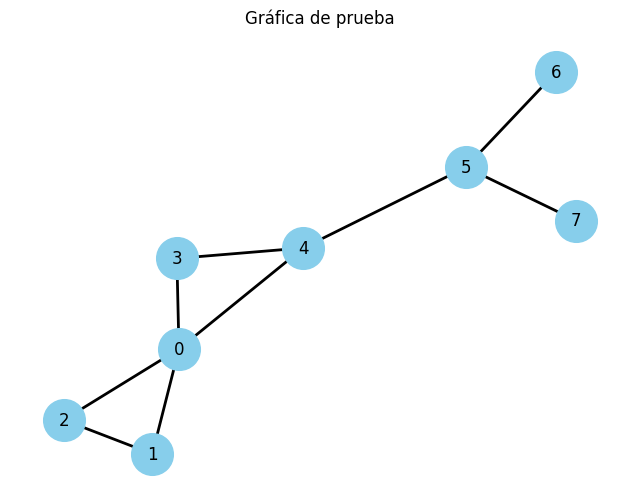

In [4]:
# Visulizar

pos1 = nx.spring_layout(G1, seed=SEED)

plt.figure(figsize=(8,6))

nx.draw_networkx(
    G1,
    pos=pos1,
    node_color='skyblue',
    node_size=900,
    width=2
)

plt.title("Gráfica de prueba")
plt.axis('off')
plt.show()

# Ejercicio 1.2 — Calcular centralidad de eigenvector
Usa `NetworkX` para calcular la centralidad.

In [5]:
eigen_central = nx.eigenvector_centrality(G1, max_iter=1000)

# Mostrar resultados ordenados

df_eigen = pd.DataFrame({
    'vértice': list(eigen_central.keys()),
    'centralidad eigenvector': list(eigen_central.values())
})

# Ordenar

df_eigen = df_eigen.sort_values(
    by='centralidad eigenvector',
    ascending=False
)

print(df_eigen)

   vértice  centralidad eigenvector
0        0                 0.576856
4        4                 0.451491
3        3                 0.386769
1        1                 0.347750
2        2                 0.347750
5        5                 0.236807
6        6                 0.089066
7        7                 0.089066


---

# Preguntas de análisis

1. ¿El vértice con la centralidad más alta coincide con el nodo de mayor grado?
- Sí, el vértice 0 tiene mayor grado y tiene la centralidad eigenvector más alta
2. ¿Por qué algunos vértices con pocos vecinos pueden tener alta centralidad?
- Porque tiene de vecinos a vértices "importantes"
4. ¿Qué interpretación tiene esta medida en redes sociales (por ejemplo, redes de amistad, de coautorías, etc.)?
- Que toma en cuenta a quienes estan conectados tus vecinos y no solo los tuyos.

---

# Ejercicio 1.4 — Visualización de la centralidad

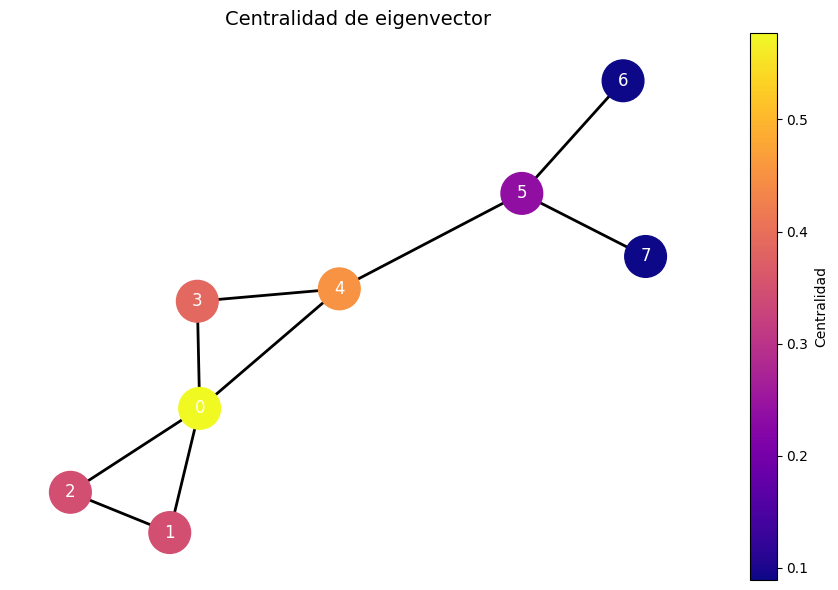

In [6]:
fig, ax = plt.subplots(figsize=(9,6))

dibuja_centralidad(
    G1,
    eigen_central,
    "Centralidad de eigenvector",
    pos=pos1,
    ax=ax
)

plt.tight_layout()
plt.show()

# Parte 2 — Comparación con centralidad de grado

Ahora comparemos la centralidad de eigenvector con la centralidad de grado.

## Ejercicio 2.1

In [7]:
grado_central = nx.degree_centrality(G1)

comparacion = pd.DataFrame({
    'grado': grado_central,
    'eigenvector': eigen_central
})

comparacion = comparacion.sort_values(
    by='eigenvector',
    ascending=False
)

print(comparacion)

      grado  eigenvector
0  0.571429     0.576856
4  0.428571     0.451491
3  0.285714     0.386769
1  0.285714     0.347750
2  0.285714     0.347750
5  0.428571     0.236807
6  0.142857     0.089066
7  0.142857     0.089066


# Ejercicio 2.2 — Visualización comparativa

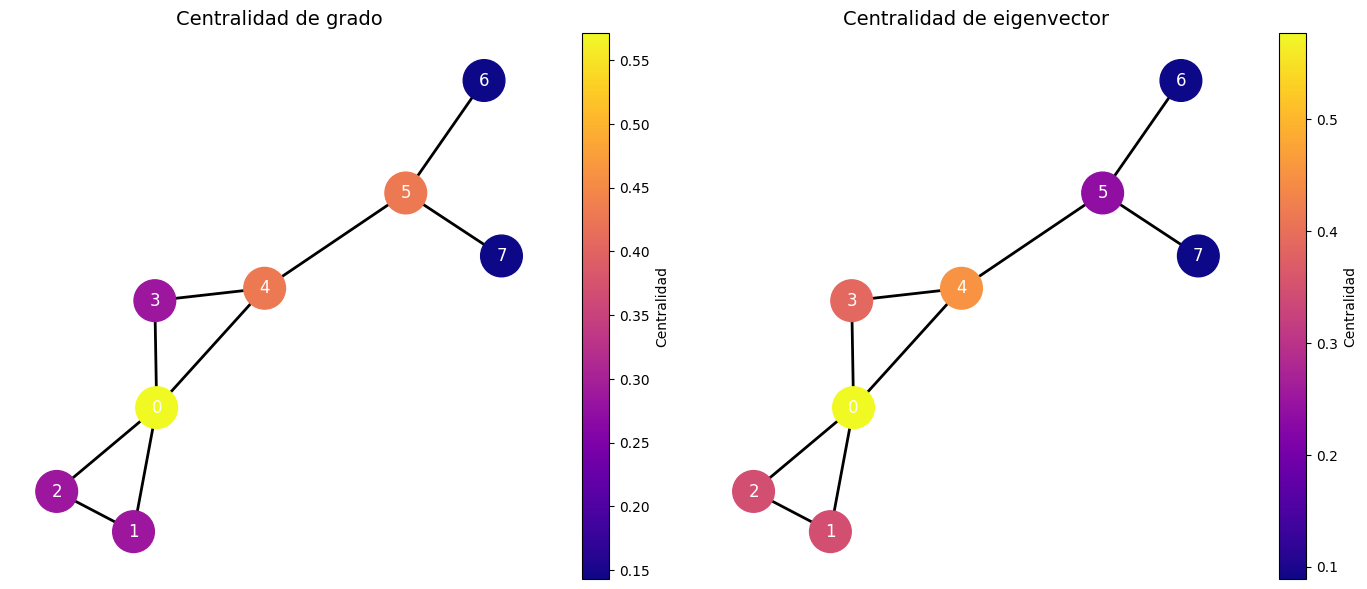

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(14,6))

# Grado

dibuja_centralidad(
    G1,
    grado_central,
    "Centralidad de grado",
    pos=pos1,
    ax=axs[0]
)

# Eigenvector

dibuja_centralidad(
    G1,
    eigen_central,
    "Centralidad de eigenvector",
    pos=pos1,
    ax=axs[1]
)

plt.tight_layout()
plt.show()

# Parte 3 — Gráfica estrella

La gráfica estrella tiene un nodo central conectado con todos los demás.

## Ejercicio 3.1

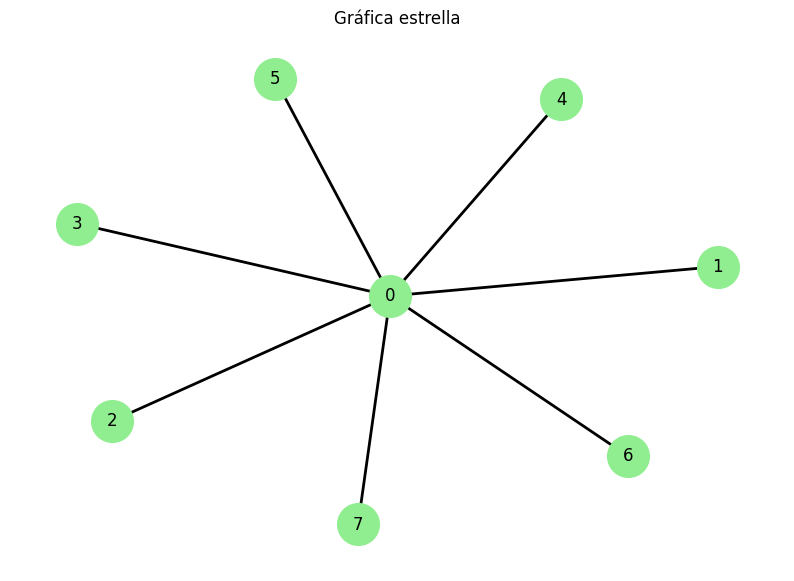

In [9]:
G2 = nx.star_graph(7)

pos2 = nx.spring_layout(G2, seed=SEED)

nx.draw_networkx(
    G2,
    pos=pos2,
    node_color='lightgreen',
    node_size=900,
    width=2
)

plt.title("Gráfica estrella")
plt.axis('off')
plt.show()

## Ejercicio 3.2 — Eigenvector en una estrella

In [10]:
eigen_star = nx.eigenvector_centrality(G2)

pd.DataFrame({
    'vértice': list(eigen_star.keys()),
    'centralidad': list(eigen_star.values())
}).sort_values(by='centralidad', ascending=False)

,vértice,centralidad
0,0,0.707107
1,1,0.267261
2,2,0.267261
3,3,0.267261
4,4,0.267261
5,5,0.267261
6,6,0.267261
7,7,0.267261


# Preguntas

1. ¿Qué nodo domina completamente la centralidad?
- El nodo 0
2. ¿Qué sucede con las hojas?
- Todas tienen la misma centralidad, aparte que es muy baja.
3. ¿Por qué esta medida favorece al nodo central?
- Porque como todos los vértices estan conectado a el, de alguna manera su importancia crece gracias a sí mismo
---

# Parte 4 — Gráfica trayectoria

En una gráfica trayectoria, los nodos centrales suelen tener mayor importancia.

## Ejercicio 4.1

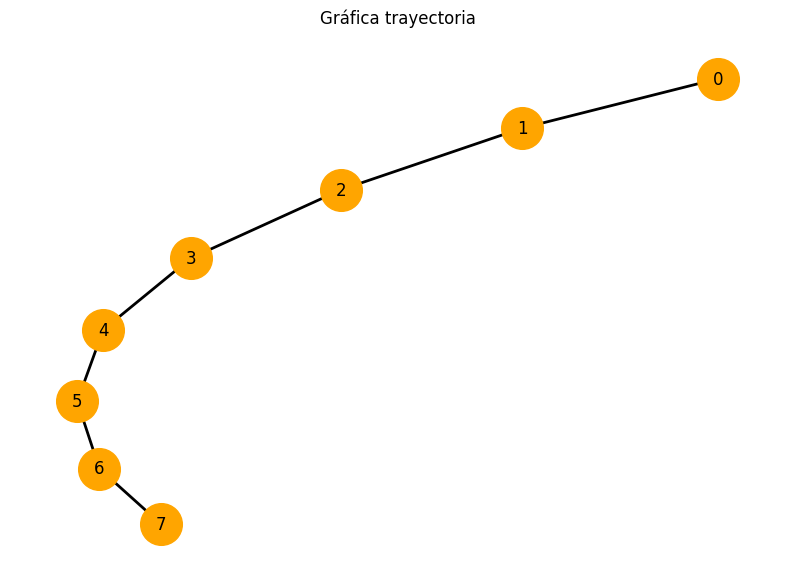

In [11]:
G3 = nx.path_graph(8)

pos3 = nx.spring_layout(G3, seed=SEED)

nx.draw_networkx(
    G3,
    pos=pos3,
    node_color='orange',
    node_size=900,
    width=2
)

plt.title("Gráfica trayectoria")
plt.axis('off')
plt.show()

## Ejercicio 4.2 — Eigenvector en una trayectoria

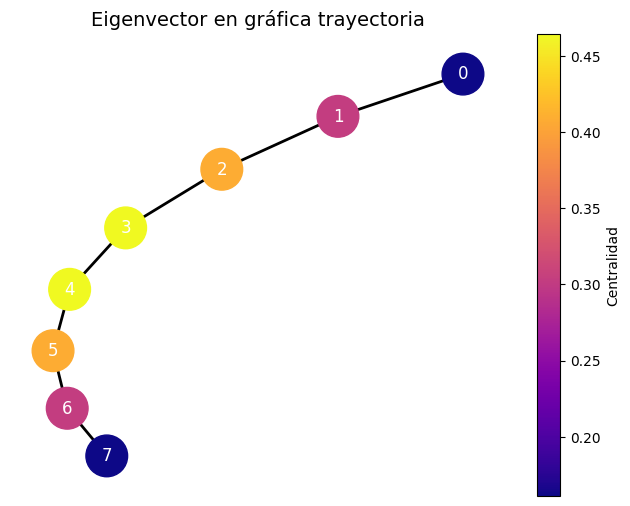

In [12]:
eigen_path = nx.eigenvector_centrality(G3)

fig, ax = plt.subplots(figsize=(8,6))

dibuja_centralidad(
    G3,
    eigen_path,
    "Eigenvector en gráfica trayectoria",
    pos=pos3,
    ax=ax
)

plt.show()

---

# Preguntas

1. ¿Qué nodos tienen mayor centralidad?
- Nodos 3 y 4 (los centrales)

2. ¿Por qué los extremos tienen valores pequeños?
- Los extremos tienen solo un vecino cada uno, como sus vecinos tampoco están bien conectados, así que la importancia no se propaga hacia ellos. En cambio, los nodos centrales tienen vecinos que a su vez tienen más vecinos, haciendo que se acumule más su importancia

3. ¿Qué relación existe entre posición estructural e importancia?
- Los nodos estructuralmente centralestienen mayor eigenvector que los periféricos. La posición en la red determina cuánta importancia acumulan porque tienen acceso a más caminos y conexiones.

---

# Parte 5 — Limitaciones

La centralidad de eigenvector tiene algunas limitaciones:

- Puede fallar en gráficas desconectadas.
- Depende del eigenvalor dominante.
- Favorece nodos conectados a hubs.
- Puede requerir varias iteraciones para converger.

En `NetworkX` se puede aumentar el número de iteraciones usando:

In [ ]:
nx.eigenvector_centrality(G, max_iter=5000)

---

# Parte 6 - Ejercicio integrador

Construye dos gráficas: la red del club Zachary y una red de de almenos 15 vértices. Para la redes de 15 vértices Puedes probar con una gráfica de tipo Erdös-Renyi, usando la función `nx.erdos_renyi_graph`. 

Para ambas gráficas analiza y reporta lo siguente:

1. Los nodos con mayor centralidad.
2. La diferencia entre grado y eigenvector.
3. Cómo influye la estructura global de la red.

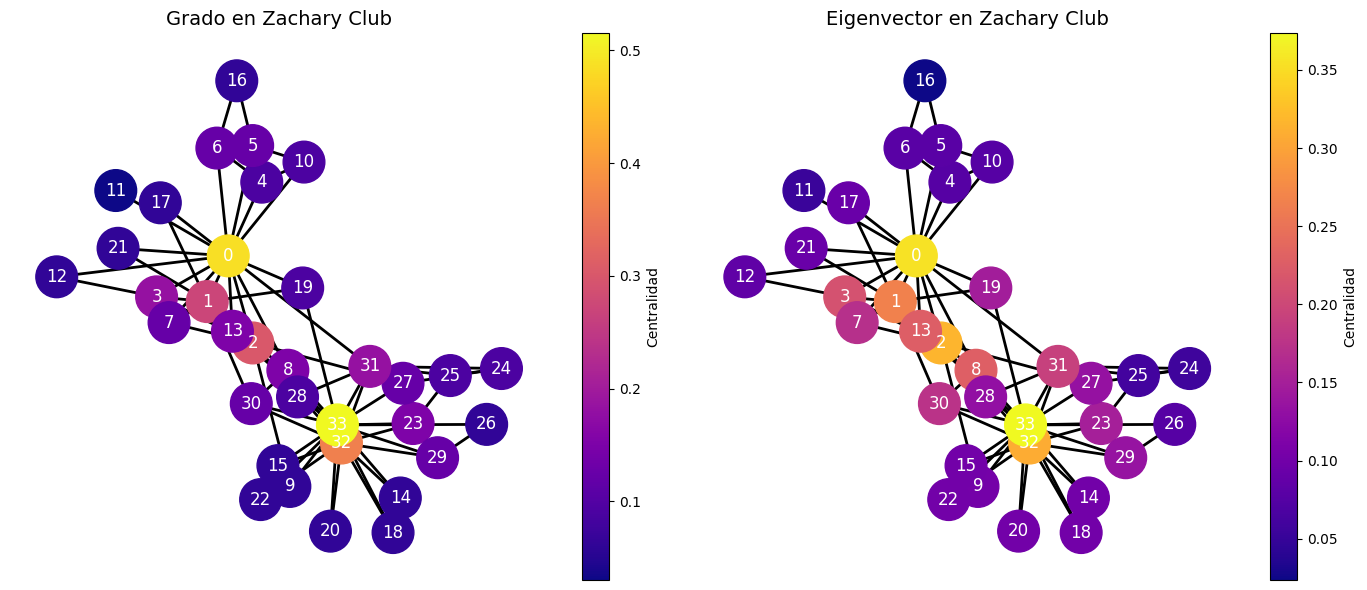

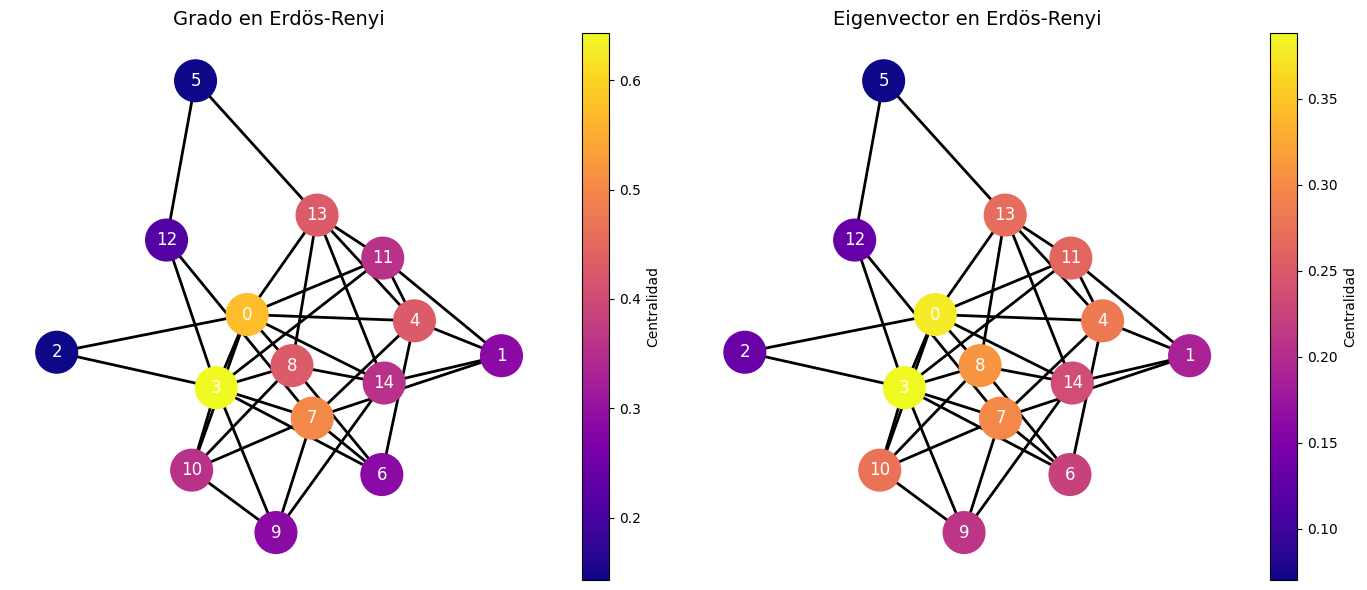

In [ ]:
#Gráfica del club Zachary
K = nx.karate_club_graph()
eigen_zachary = nx.eigenvector_centrality(K, max_iter=1000)
grado_zachary = nx.degree_centrality(K)

#Visualizar
pos_zachary = nx.spring_layout(K, seed=SEED)
fig, axs = plt.subplots(1, 2, figsize=(14,6))

dibuja_centralidad(K, grado_zachary, "Grado en Zachary Club", pos=pos_zachary, ax=axs[0])
dibuja_centralidad(K, eigen_zachary, "Eigenvector en Zachary Club", pos=pos_zachary, ax=axs[1])

plt.tight_layout()
plt.show()


#Red Erdös-Renyi
G_erdos = nx.erdos_renyi_graph(n=15, p=0.3, seed=SEED)
pos_erdos = nx.spring_layout(G_erdos, seed=SEED)
eigen_erdos = nx.eigenvector_centrality(G_erdos, max_iter=1000)
grado_erdos = nx.degree_centrality(G_erdos)


# Visualización comparativa
fig, axs = plt.subplots(1, 2, figsize=(14,6))

dibuja_centralidad(G_erdos, grado_erdos, "Grado en Erdös-Renyi", pos=pos_erdos, ax=axs[0])
dibuja_centralidad(G_erdos, eigen_erdos, "Eigenvector en Erdös-Renyi", pos=pos_erdos, ax=axs[1])

plt.tight_layout()
plt.show()



1. Nodos con mayor centralidad 
   Club de Zachary:
   - Nodo con máximo eigenvector: 33 
   - Nodo con máximo grado: 33

   Red Erdös-Renyi:
   - Nodo con máximo eigenvector: 3 
   - Nodo con máximo grado: 3 
2. Diferencia entre grado y eigenvector
   -  Grado evalúa a un nodo únicamente por el número de vecinos directos que tiene, sin importar quiénes sean.
   -  Eigenvector valúa a un nodo en función de la importancia de sus vecinos
3. Cómo influye la estructura global de la red.
   - Se puede observar que para la red Erdös-Renyi se ven más relacionados los valores de grado y eigenvector, esto puede ser a causa de que no hay nodos más importantes que otros al crearla aleatoria mente, la estructura carece de hubs o nodos con muchos vecinos. A diferencia del club de Zachary donde la estructura global está centrada en torno a líderes, haciendo que el eigenvector se concentre fuertemente en ellos, haciendo grande la diferencia con el Grado.

# Conclusiones

En esta práctica observaste que:

- La centralidad de eigenvector considera la importancia de los vecinos.
- No basta con tener muchos enlaces; importa con quién estás conectado.
- Esta medida captura mejor la influencia global dentro de la red.
- Diferentes estructuras producen distribuciones distintas de centralidad.

### Para tu reporte

Entrega este notebook ejecutado, con todas las preguntas respondidas y el ejercicio integrador completo.

### Lecturas recomendadas

- Coscia, M. *The Atlas for the Aspiring Network Scientist*. Cap 4 (centrality).  
- Newman, M. E. J. *Networks: An Introduction*. Cap. 7 (centralidad).